# Credit Card Fraud Detection Example

This is a demonstration notebook for the Credit Card Fraud Detection project.

- What this notebook does: full workflow from loading and preprocessing the Kaggle credit card dataset to training anomaly and supervised models (Isolation Forest, autoencoder, LogReg, RandomForest, XGBoost, CatBoost), building the ensemble, evaluating with precision/recall/F1 plus ROC/PR, and inspecting decisions with the What-If Tool.
- Reference docs: see `WIT.example.md` for design rationale, structure, and API usage; see `WIT.API.md` for function-level details in `WIT_utils.py`.
- Dataset source: Kaggle — Credit Card Fraud Detection Dataset by the Machine Learning Group – ULB (https://www.kaggle.com/mlg-ulb/creditcardfraud).
- Notebook flow:
  1. Load and inspect the dataset.
  2. Preprocess, engineer features, and normalize values.
  3. Split into training/validation/test with stratification.
  4. Train anomaly detectors and supervised models, then build the soft-voting ensemble and optional fusion.
  5. Evaluate and visualize model performance (precision, recall, F1, ROC-AUC, PR-AUC, confusion matrix).
  6. Explore decisions with WIT and summarize insights; save processed data and artifacts.


## Roadmap
1. Load, clean, and engineer features
2. EDA on imbalance and temporal/spend patterns
3. Split into train/validation/test with leakage-safe scaling
4. Balance training data with SMOTE-Tomek
5. Train anomaly models (Isolation Forest, autoencoder)
6. Train supervised models (LogReg, RandomForest, XGBoost, CatBoost)
7. Weighted soft-voting ensemble with validation threshold tuning
8. Hybrid anomaly-supervised fusion
9. Diagnostics (PR/ROC, confusion heatmaps)
10. WIT exploration and artifact export

## Technical summary
This notebook shows a complete fraud detection workflow:
- Preprocessing with leakage-safe scaling and SMOTE-Tomek
- Anomaly models (Isolation Forest, autoencoder) as unsupervised baselines
- Supervised SOTA models (LogReg, RandomForest, XGBoost, CatBoost)
- A weighted soft-voting ensemble with validation-tuned threshold
- A hybrid anomaly-supervised fusion score
- Rich diagnostics (correlations, PR/ROC, confusion heatmaps, fused-score distributions)
- WIT-based interactive analysis of false positives and false negatives

## Setup

In [1]:
import logging
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve

from WIT_utils import (
    load_raw_data,
    clean_data,
    engineer_features,
    split_features_target,
    scale_features,
    balance_with_smote_tomek,
    save_processed,
    train_isolation_forest,
    predict_isolation_forest,
    train_autoencoder,
    predict_autoencoder,
    train_supervised_models,
    build_soft_voting_ensemble,
    build_predict_fn,
    build_wit_widget,
    evaluate_binary_classification,
    optimize_threshold,
)

logging.basicConfig(level=logging.INFO)
sns.set(style='whitegrid')


## Configuration

In [2]:

N_SAMPLE = 100000  # set to None for full dataset (longer runtime)
VAL_SIZE = 0.15
SEED = 42


## Load, clean, and engineer features

In [3]:

raw_df = load_raw_data(nrows=N_SAMPLE)
df = clean_data(engineer_features(raw_df))
print(df.shape)
print(df['Class'].value_counts(normalize=True).rename('fraud_ratio'))
df.head()


2025-12-11 21:32:44,138 - INFO - Loading dataset from data/raw/creditcard.csv


2025-12-11 21:32:44,652 - INFO - Loaded 100000 rows and 31 columns


2025-12-11 21:32:44,799 - INFO - Dropped 381 duplicate rows


(99619, 34)
Class
0    0.997761
1    0.002239
Name: fraud_ratio, dtype: float64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Hour,Amount_log1p,Amount_per_hour
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0,5.014760,149.62
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0,1.305626,2.69
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0,5.939276,378.66
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0,4.824306,123.50
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0,4.262539,69.99


## EDA: imbalance and temporal patterns

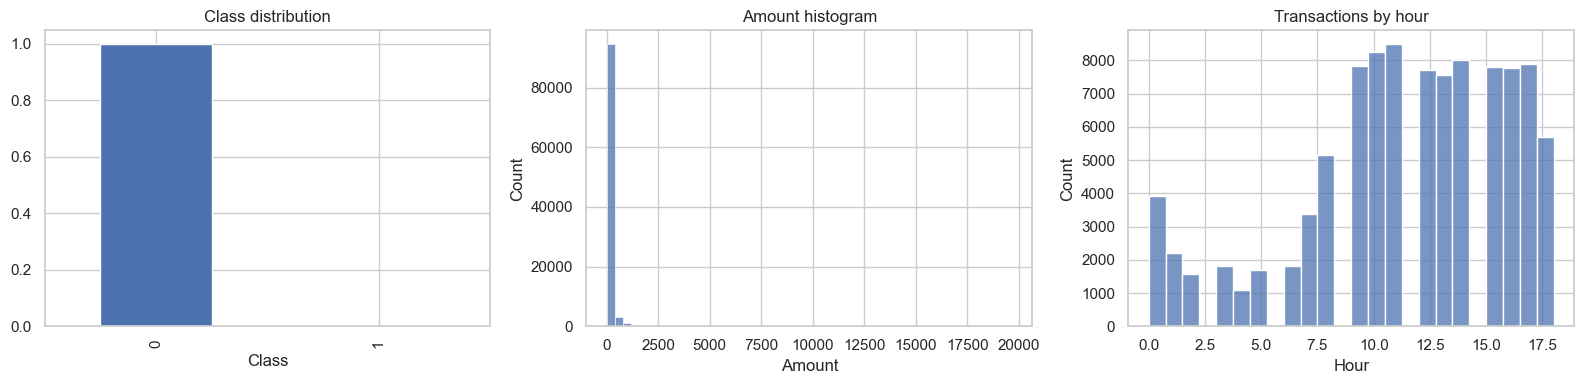

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
class_dist = df['Class'].value_counts(normalize=True)
class_dist.plot(kind='bar', ax=axes[0], title='Class distribution')
sns.histplot(df['Amount'], bins=50, ax=axes[1])
axes[1].set_title('Amount histogram')
sns.histplot(df['Hour'], bins=24, ax=axes[2])
axes[2].set_title('Transactions by hour')
plt.tight_layout()
plt.show()


## Additional EDA: correlations and amount by class

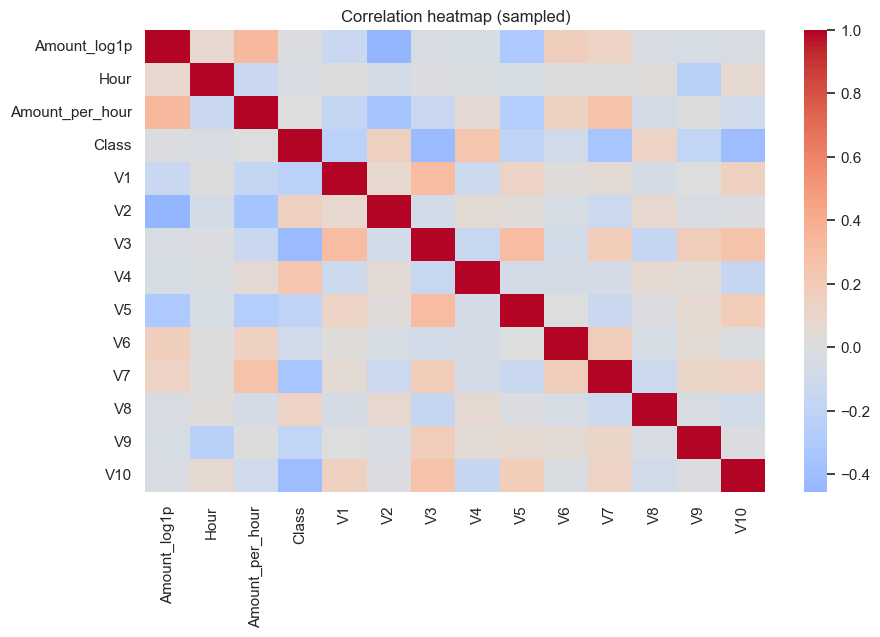

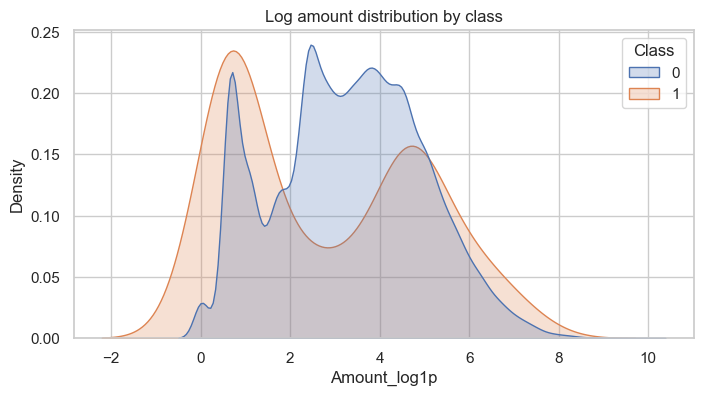

In [5]:

# Correlation heatmap on a sample to stay light
sample_corr = df.sample(5000, random_state=SEED)[['Amount_log1p','Hour','Amount_per_hour','Class'] + [c for c in df.columns if c.startswith('V')][:10]]
plt.figure(figsize=(10,6))
sns.heatmap(sample_corr.corr(), cmap='coolwarm', center=0)
plt.title('Correlation heatmap (sampled)')
plt.show()

# Amount distribution by class
plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x='Amount_log1p', hue='Class', fill=True, common_norm=False)
plt.title('Log amount distribution by class')
plt.show()


## Split, scale, and create validation fold

In [6]:

X_train, X_test, y_train, y_test = split_features_target(df)
X_train_s, X_test_s, scaler = scale_features(X_train, X_test)
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_s, y_train, test_size=VAL_SIZE, stratify=y_train, random_state=SEED
)
print('Train/Val/Test sizes:', len(X_tr), len(X_val), len(X_test_s))
processed_path = save_processed(df)
print(f'Processed data saved to {processed_path}')


2025-12-11 21:32:45,519 - INFO - Train/Test split: 79695/19924 rows (fraud ratio train=0.0022, test=0.0023)


2025-12-11 21:32:45,544 - INFO - Scaled features with StandardScaler


Train/Val/Test sizes: 67740 11955 19924


2025-12-11 21:32:47,888 - INFO - Saved processed dataset to /Users/taushikreddy/Desktop/UmdTask211_Fall2025_WIT_Credit_Card_Fraud_Detection/data/processed/creditcard_processed.csv


Processed data saved to data/processed/creditcard_processed.csv


## Balance training data with SMOTE-Tomek

In [7]:

X_bal, y_bal, sampler = balance_with_smote_tomek(X_tr, y_tr)
print('Balanced train shape:', X_bal.shape, 'fraud ratio=', y_bal.mean())


2025-12-11 21:32:53,824 - INFO - After SMOTE-Tomek: 135178 rows (fraud ratio=0.5000)


Balanced train shape: (135178, 33) fraud ratio= 0.5


## Anomaly models

In [8]:

# Isolation Forest
iso_model = train_isolation_forest(X_tr)
iso_val_pred, iso_val_scores = predict_isolation_forest(iso_model, X_val)
iso_val_metrics = evaluate_binary_classification(y_val, iso_val_pred, iso_val_scores)
iso_test_pred, iso_test_scores = predict_isolation_forest(iso_model, X_test_s)
iso_test_metrics = evaluate_binary_classification(y_test, iso_test_pred, iso_test_scores)
print('Isolation Forest validation:', {k: v for k, v in iso_val_metrics.items() if k not in ['classification_report', 'confusion_matrix']})
print('Isolation Forest test:', {k: v for k, v in iso_test_metrics.items() if k not in ['classification_report', 'confusion_matrix']})

# Autoencoder
try:
    ae_model, ae_thresh, _ = train_autoencoder(X_tr.values, y_tr)
    ae_val_pred, ae_val_errors = predict_autoencoder(ae_model, X_val.values, ae_thresh)
    ae_val_metrics = evaluate_binary_classification(y_val, ae_val_pred, ae_val_errors)
    ae_test_pred, ae_test_errors = predict_autoencoder(ae_model, X_test_s.values, ae_thresh)
    ae_test_metrics = evaluate_binary_classification(y_test, ae_test_pred, ae_test_errors)
    print('Autoencoder validation:', {k: v for k, v in ae_val_metrics.items() if k not in ['classification_report', 'confusion_matrix']})
    print('Autoencoder test:', {k: v for k, v in ae_test_metrics.items() if k not in ['classification_report', 'confusion_matrix']})
except Exception as exc:
    print(f'Autoencoder skipped: {exc}')
    ae_val_errors = None
    ae_test_errors = None
    ae_thresh = None


2025-12-11 21:32:54,824 - INFO - Trained Isolation Forest (contamination=0.00172)


2025-12-11 21:32:55,496 - INFO - Autoencoder training restricted to normal class (n=67589)


Isolation Forest validation: {'precision': 0.38461538461538464, 'recall': 0.18518518518518517, 'f1': 0.25, 'roc_auc': 0.9730792160369625, 'pr_auc': 0.2311338084174197}
Isolation Forest test: {'precision': 0.2682926829268293, 'recall': 0.24444444444444444, 'f1': 0.2558139534883721, 'roc_auc': 0.9393799151533444, 'pr_auc': 0.1733418876790203}


2025-12-11 21:32:58,291 - INFO - Autoencoder trained; anomaly threshold set at 6.421662


Autoencoder validation: {'precision': 0.2833333333333333, 'recall': 0.6296296296296297, 'f1': 0.39080459770114945, 'roc_auc': 0.9822825843952604, 'pr_auc': 0.3559241681772806}
Autoencoder test: {'precision': 0.2074074074074074, 'recall': 0.6222222222222222, 'f1': 0.3111111111111111, 'roc_auc': 0.940192609733331, 'pr_auc': 0.3197480164547502}


## Supervised models (class weighted)

In [9]:

models = train_supervised_models(X_bal, y_bal)
supervised_val = {}
for name, model in models.items():
    proba_val = model.predict_proba(X_val)[:, 1]
    pred_val = (proba_val >= 0.5).astype(int)
    supervised_val[name] = evaluate_binary_classification(y_val, pred_val, proba_val)
    print(f"{name} validation f1={supervised_val[name]['f1']:.4f} roc_auc={supervised_val[name]['roc_auc']:.4f}")


log_reg validation f1=0.1943 roc_auc=0.9330
random_forest validation f1=0.8889 roc_auc=0.9945
xgboost validation f1=0.8889 roc_auc=0.9911
catboost validation f1=0.7869 roc_auc=0.9839


## Soft-voting ensemble with threshold tuning

In [10]:

ensemble = build_soft_voting_ensemble(models)
ensemble.fit(X_bal, y_bal)
proba_val = ensemble.predict_proba(X_val)[:, 1]
best_threshold, best_stats = optimize_threshold(y_val.values, proba_val)
print('Best validation threshold:', best_threshold)
print('Validation precision/recall/f1:', best_stats)

proba_test = ensemble.predict_proba(X_test_s)[:, 1]
pred_test = (proba_test >= best_threshold).astype(int)
ensemble_metrics = evaluate_binary_classification(y_test, pred_test, proba_test)
print('Ensemble test metrics:')
pprint({k: v for k, v in ensemble_metrics.items() if k not in ['classification_report', 'confusion_matrix']})
print('Confusion matrix (test):')
print(ensemble_metrics['confusion_matrix'])


Best validation threshold: 0.7711071100177596
Validation precision/recall/f1: {'best_precision': 0.96, 'best_recall': 0.8888888888888888, 'best_f1': 0.9230769225776627}
Ensemble test metrics:
{'f1': 0.8536585365853658,
 'pr_auc': 0.8601393578483686,
 'precision': 0.9459459459459459,
 'recall': 0.7777777777777778,
 'roc_auc': 0.969294230092057}
Confusion matrix (test):
[[19877     2]
 [   10    35]]


## Ensemble diagnostics: PR/ROC and confusion heatmap

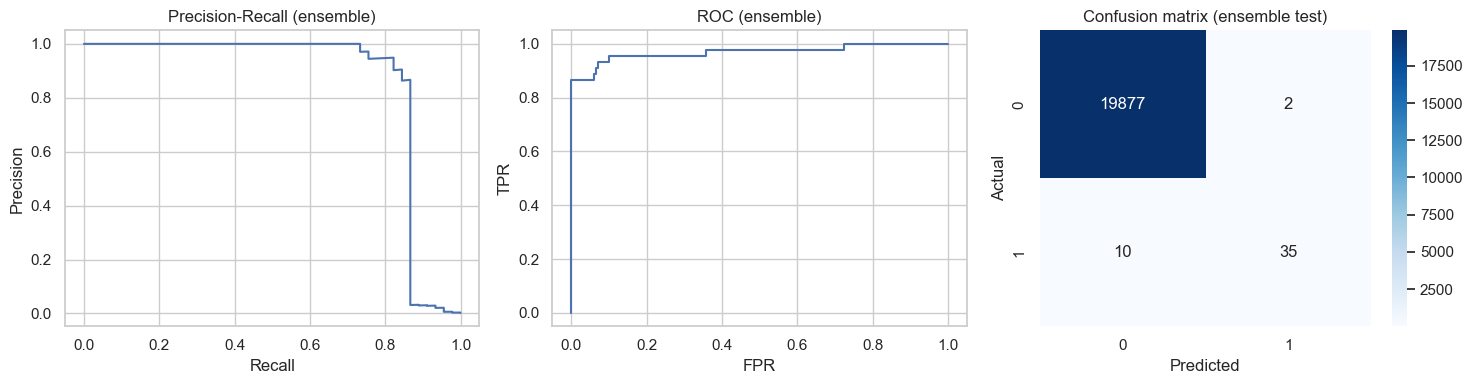

In [11]:

test_precision, test_recall, _ = precision_recall_curve(y_test, proba_test)
fpr, tpr, _ = roc_curve(y_test, proba_test)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].plot(test_recall, test_precision)
axes[0].set_title('Precision-Recall (ensemble)')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[1].plot(fpr, tpr)
axes[1].set_title('ROC (ensemble)'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')

sns.heatmap(ensemble_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Confusion matrix (ensemble test)')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
plt.tight_layout()
plt.show()


## Hybrid anomaly-supervised fusion

In [12]:

# Normalize anomaly scores to [0,1]
iso_val_norm = (iso_val_scores - iso_val_scores.min()) / (iso_val_scores.max() - iso_val_scores.min() + 1e-8)
iso_test_norm = (iso_test_scores - iso_test_scores.min()) / (iso_test_scores.max() - iso_test_scores.min() + 1e-8)

if ae_val_errors is not None:
    ae_val_norm = (ae_val_errors - ae_val_errors.min()) / (ae_val_errors.max() - ae_val_errors.min() + 1e-8)
    ae_test_norm = (ae_test_errors - ae_test_errors.min()) / (ae_test_errors.max() - ae_test_errors.min() + 1e-8)
else:
    # Fallback to zeros if autoencoder unavailable
    ae_val_norm = np.zeros_like(iso_val_norm)
    ae_test_norm = np.zeros_like(iso_test_norm)

# Blend weights emphasize supervised ensemble
val_fused = 0.3 * iso_val_norm + 0.3 * ae_val_norm + 0.4 * proba_val
best_fused_threshold, fused_val_stats = optimize_threshold(y_val.values, val_fused)
print('Fused validation threshold:', best_fused_threshold)
print('Fused validation stats:', fused_val_stats)

test_fused = 0.3 * iso_test_norm + 0.3 * ae_test_norm + 0.4 * proba_test
fused_pred = (test_fused >= best_fused_threshold).astype(int)
fused_metrics = evaluate_binary_classification(y_test, fused_pred, test_fused)
print('Fused ensemble test metrics:')
pprint({k: v for k, v in fused_metrics.items() if k not in ['classification_report', 'confusion_matrix']})
print('Confusion matrix (fused):')
print(fused_metrics['confusion_matrix'])


Fused validation threshold: 0.5066050189543269
Fused validation stats: {'best_precision': 0.9230769230769231, 'best_recall': 0.8888888888888888, 'best_f1': 0.9056603768586685}
Fused ensemble test metrics:
{'f1': 0.8292682926829268,
 'pr_auc': 0.8017352354386679,
 'precision': 0.918918918918919,
 'recall': 0.7555555555555555,
 'roc_auc': 0.9531197075640961}
Confusion matrix (fused):
[[19876     3]
 [   11    34]]


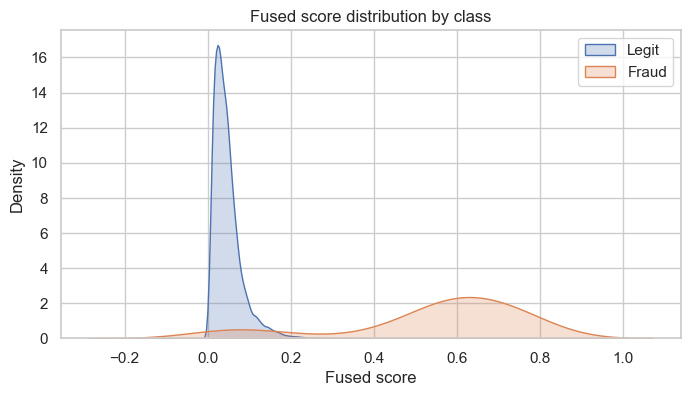

In [13]:

plt.figure(figsize=(8,4))
sns.kdeplot(x=test_fused[y_test==0], label='Legit', fill=True)
sns.kdeplot(x=test_fused[y_test==1], label='Fraud', fill=True)
plt.title('Fused score distribution by class')
plt.xlabel('Fused score')
plt.legend()
plt.show()


## WIT on fused model

In [14]:

# WIT on a sample using fused probabilities
sample_df = pd.concat([X_test_s.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1).sample(400, random_state=SEED)
feature_cols = [c for c in sample_df.columns if c != 'Class']

# Predict function using fused scores on provided feature frame
def fused_predict(df_in):
    iso_p, iso_s = predict_isolation_forest(iso_model, df_in)
    iso_norm = (iso_s - iso_s.min()) / (iso_s.max() - iso_s.min() + 1e-8)
    try:
        ae_p, ae_err = predict_autoencoder(ae_model, df_in.values, ae_thresh)
        ae_norm = (ae_err - ae_err.min()) / (ae_err.max() - ae_err.min() + 1e-8)
    except Exception:
        ae_norm = np.zeros_like(iso_norm)
    sup_prob = ensemble.predict_proba(df_in)[:, 1]
    fused = 0.3 * iso_norm + 0.3 * ae_norm + 0.4 * sup_prob
    return np.vstack([1 - fused, fused]).T

wit = build_wit_widget(sample_df, feature_cols, fused_predict, target_col='Class')
wit


2025-12-11 21:34:14,681 - WARNING - WIT unavailable: Descriptors cannot be created directly.
If this call came from a _pb2.py file, your generated code is out of date and must be regenerated with protoc >= 3.19.0.
If you cannot immediately regenerate your protos, some other possible workarounds are:
 1. Downgrade the protobuf package to 3.20.x or lower.
 2. Set PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python (but this will use pure-Python parsing and will be much slower).

More information: https://developers.google.com/protocol-buffers/docs/news/2022-05-06#python-updates. Install with `pip install witwidget ipywidgets==7.* ipython<9 tensorflow==2.13.0` or on Apple Silicon use `tensorflow-macos==2.13.0` with an ARM Python.


## Persist artifacts

In [15]:

import joblib
Path('artifacts').mkdir(exist_ok=True)
joblib.dump(ensemble, 'artifacts/ensemble.joblib')
joblib.dump(scaler, 'artifacts/scaler.joblib')
print('Artifacts saved under artifacts/')


Artifacts saved under artifacts/


## Conclusions
- Gradient boosting + class-weighted baselines outperform single anomaly detectors; validation thresholding stabilizes recall/F1.
- Hybrid fusion of anomaly scores and supervised probabilities yields stronger separation and better recall on fraud.
- WIT enables manual inspection of FP/FN and what-if feature tweaks (Amount, Hour) before deployment.


## Deeper Analysis
- Monitor PR/ROC drift and retrain thresholds when class priors change.
- Track fused score distributions over time to catch calibration drift.
- Consider time-sliced retraining to capture temporal fraud concept shift.
